# BC Losses Analysis — Dirichlet & Neumann

**Goal:** understand how the two new boundary condition losses behave spatially
on the trained model and whether they are actually reducing the errors they were
designed to fix.

| Loss | Location | Expression | What it encodes |
|------|----------|------------|-----------------|
| `dirichlet_loss` | x = 0 mm | `T̂ = T_fix` | Fixed temperature anchor |
| `neumann_loss`   | x = L = 1000 mm | `∂T̂/∂x = q/(k·A)` | Heat-flux slope |

**Notebook: `bc_losses_analysis.ipynb`**  
Run after training (`saves/thermal_pinn.pt` must exist).

In [39]:
import sys, json
from pathlib import Path

import numpy as np
import torch
import meshio
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display as ipy_display
from scipy.stats import spearmanr

ROOT        = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
from arch import ThermalNet

ELMER_CASES = ROOT / 'elmer_cases' / 'thermal_ccx_beam'
SAVES       = ROOT / 'saves'
LOG_COLS    = [3]

# Beam geometry
X_MIN_MM      = 0.0
X_MAX_MM      = 1000.0
BEAM_AREA_MM2 = 10_000.0   # 100 mm × 100 mm
BC_TOL_MM     = 20.0       # same tolerance used in losses.py

MATERIAL_K = {
    'Steel_A36':        50.0,
    'Steel_S355':       48.0,
    'Aluminium_6061':  167.0,
    'Titanium_Ti6Al4V':  6.7,
    'Concrete_C30':      1.8,
}

print('ROOT:', ROOT)
print('PyTorch:', torch.__version__)

ROOT: /home/riccardo/Documents/AI_for_NumSim/01_beam_studies/Beam_FEM_Thermal_CCX
PyTorch: 2.7.1


## 1 — Load model and normalisation parameters

In [40]:
ckpt  = torch.load(SAVES / 'thermal_pinn.pt', map_location='cpu', weights_only=True)
model = ThermalNet(hidden=ckpt['hidden'])
state = ckpt['model_state']
if any(k.startswith('module.') for k in state):
    state = {k[len('module.'):]: v for k, v in state.items()}
model.load_state_dict(state)
model.eval()

norm   = dict(np.load(SAVES / 'norm_params.npz'))
X_mean = norm['X_mean']   # (6,)
X_std  = norm['X_std']    # (6,)
Y_mean = float(norm['Y_mean'])
Y_std  = float(norm['Y_std'])

n_params = sum(p.numel() for p in model.parameters())
print(f'ThermalNet  hidden={ckpt["hidden"]}  params={n_params:,}')
print(f'X_mean = {X_mean}')
print(f'X_std  = {X_std}')
print(f'Y_mean = {Y_mean:.2f} °C    Y_std = {Y_std:.2f} °C')

# Normalised x-coordinates of both faces
x0_norm = (X_MIN_MM - X_mean[0]) / X_std[0]
xL_norm = (X_MAX_MM - X_mean[0]) / X_std[0]
tol_norm = BC_TOL_MM / X_std[0]
print(f'\nDirichlet face  x_norm ≈ {x0_norm:.4f}  (±{tol_norm:.4f})')
print(f'Neumann   face  x_norm ≈ {xL_norm:.4f}  (±{tol_norm:.4f})')

ThermalNet  hidden=512  params=792,065
X_mean = [499.1243    49.6726    49.686653   8.826892  52.344334  19.602581]
X_std  = [295.76358     34.0049      33.97192      1.5437715   58.89446
   0.39934832]
Y_mean = 243.45 °C    Y_std = 699.79 °C

Dirichlet face  x_norm ≈ -1.6876  (±0.0676)
Neumann   face  x_norm ≈ 1.6935  (±0.0676)


/tmp/ipykernel_112771/3748959887.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_mean = float(norm['Y_mean'])
/tmp/ipykernel_112771/3748959887.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_std  = float(norm['Y_std'])


## 2 — Helper functions

### 2a — Data loading and normalisation

In [41]:
def normalise_X(X: np.ndarray) -> np.ndarray:
    X_p = X.copy()
    for c in LOG_COLS:
        X_p[:, c] = np.log(X_p[:, c])
    return ((X_p - X_mean) / X_std).astype(np.float32)


def load_case(case_id: str) -> dict:
    """
    Load one case and return a dict with:
      coords   (N, 3)  — x, y, z in mm
      true_C   (N,)    — FEM temperature [°C]
      X_n      (N, 6)  — normalised feature matrix
      pred_C   (N,)    — model prediction [°C]
      params   dict    — case metadata
      k_val    float   — conductivity [mW/mm/°C]
    """
    case_dir  = ELMER_CASES / case_id
    params    = json.loads((case_dir / 'case_params.json').read_text())
    mesh      = meshio.read(str(case_dir / 'case.vtk'))
    coords    = mesh.points.astype(np.float32)              # (N, 3)

    temp_key  = next(k for k in mesh.point_data if k.lower() == 'temperature')
    true_C    = mesh.point_data[temp_key].squeeze().astype(np.float32)

    k_val     = MATERIAL_K.get(params['material'], params.get('k_mW_mm_C', 1.0))
    N         = len(coords)
    case_feats = np.tile(
        np.array([params['q_total_mW'], k_val, params['T_fix_C']], dtype=np.float32),
        (N, 1)
    )
    X         = np.hstack([coords, case_feats])             # (N, 6)
    X_n       = normalise_X(X)

    with torch.no_grad():
        Y_n   = model(torch.from_numpy(X_n)).numpy()        # (N, 1)
    pred_C    = (Y_n * Y_std + Y_mean).squeeze().astype(np.float32)

    return dict(coords=coords, true_C=true_C, X_n=X_n,
                pred_C=pred_C, params=params, k_val=k_val)


print('Data helpers defined.')

Data helpers defined.


### 2b — Per-node BC residual functions

These mirror exactly the logic in `src/losses.py` but return per-node arrays
instead of a scalar loss, so we can inspect the spatial pattern.

In [42]:
def compute_dirichlet_residuals(X_n: np.ndarray, pred_C: np.ndarray,
                                T_fix: float) -> tuple:
    """
    For nodes near x=0, return the signed and absolute temperature error
    between the model prediction and T_fix.

    Returns
    -------
    mask      : (N,) bool   — True for Dirichlet face nodes
    residual  : (M,) float  — T̂(°C) - T_fix(°C)  at face nodes  (signed)
    """
    mask     = np.abs(X_n[:, 0] - x0_norm) < tol_norm
    residual = pred_C[mask] - T_fix
    return mask, residual


def compute_neumann_residuals(X_n: np.ndarray,
                              q_mW: float, k_val: float,
                              batch_size: int = 512) -> tuple:
    """
    For nodes near x=L, compute the predicted temperature gradient ∂T̂/∂x
    (in physical °C/mm) and compare it to the analytical target q/(k·A).

    Returns
    -------
    mask          : (N,) bool   — True for Neumann face nodes
    pred_grad     : (M,) float  — predicted ∂T/∂x  [°C/mm]
    target_grad   : float       — analytical q/(k·A)  [°C/mm]
    residual      : (M,) float  — pred_grad - target_grad  (signed)
    """
    mask         = np.abs(X_n[:, 0] - xL_norm) < tol_norm
    X_bc         = X_n[mask]             # (M, 6)
    target_grad  = (q_mW / 1000.0) / (k_val * BEAM_AREA_MM2)  # W / (mW/mm/°C * mm²)
    # q in mW, k in mW/mm/°C, A in mm² → gradient in °C/mm
    target_grad  = q_mW / (k_val * BEAM_AREA_MM2)             # °C/mm

    all_grad = []
    for start in range(0, len(X_bc), batch_size):
        xb = torch.from_numpy(X_bc[start:start + batch_size])   # (B, 6)
        with torch.enable_grad():
            x  = xb.clone().detach().requires_grad_(True)
            T  = model(x)                                         # (B, 1)
            dT_dx_norm = torch.autograd.grad(
                T.sum(), x, create_graph=False
            )[0][:, 0].detach().numpy()                          # (B,) normalised
        # Convert normalised gradient to physical [°C/mm]
        dT_dx_phys = dT_dx_norm * Y_std / X_std[0]
        all_grad.append(dT_dx_phys)

    pred_grad = np.concatenate(all_grad).astype(np.float32)
    residual  = pred_grad - target_grad
    return mask, pred_grad, target_grad, residual


print('BC residual helpers defined.')

BC residual helpers defined.


---
## 3 — Single-case deep dive

We pick one **interpolation** test case (Steel_A36, Q≈52.5 W) as the reference.
The beam spans x = [0, 1000] mm.

In [47]:
CASE_ID = 'case_0102'   # Steel_A36, Q=52.5 W, interpolation

print(f'Loading {CASE_ID} …')
case   = load_case(CASE_ID)
params = case['params']
coords = case['coords']
true_C = case['true_C']
pred_C = case['pred_C']
X_n    = case['X_n']
k_val  = case['k_val']
q_mW   = params['q_total_mW']
T_fix  = params['T_fix_C']

err    = np.abs(pred_C - true_C)

print(f'  Material : {params["material"]}   k = {k_val} mW/mm/°C')
print(f'  Q        : {q_mW:.1f} mW  ({q_mW/1000:.3f} W)')
print(f'  T_fix    : {T_fix} °C')
print(f'  Nodes    : {len(coords):,}')
print(f'  MAE      : {err.mean():.3f} °C   max |ΔT| = {err.max():.3f} °C')

# BC residuals
dir_mask, dir_res = compute_dirichlet_residuals(X_n, pred_C, T_fix)
neu_mask, neu_pred_grad, neu_target_grad, neu_res = compute_neumann_residuals(
    X_n, q_mW, k_val)

print(f'\n--- Dirichlet face (x≈0) ---')
print(f'  Nodes in face : {dir_mask.sum()}')
print(f'  T̂ - T_fix    : mean={dir_res.mean():.4f} °C   std={dir_res.std():.4f} °C   max|·|={np.abs(dir_res).max():.4f} °C')

print(f'\n--- Neumann face (x≈L) ---')
print(f'  Nodes in face    : {neu_mask.sum()}')
print(f'  Target ∂T/∂x     : {neu_target_grad:.6f} °C/mm')
print(f'  Predicted ∂T/∂x  : mean={neu_pred_grad.mean():.6f}   std={neu_pred_grad.std():.6f} °C/mm')
print(f'  Residual (pred-target): mean={neu_res.mean():.6f}   max|·|={np.abs(neu_res).max():.6f} °C/mm')
print(f'  Relative Neumann error: {np.abs(neu_res).mean()/neu_target_grad*100:.2f} %')

Loading case_0102 …
  Material : Steel_A36   k = 50.0 mW/mm/°C
  Q        : 52500.0 mW  (52.500 W)
  T_fix    : 20.0 °C
  Nodes    : 9,314
  MAE      : 6.430 °C   max |ΔT| = 13.414 °C

--- Dirichlet face (x≈0) ---
  Nodes in face : 286
  T̂ - T_fix    : mean=4.6268 °C   std=0.7286 °C   max|·|=6.4201 °C

--- Neumann face (x≈L) ---
  Nodes in face    : 285
  Target ∂T/∂x     : 0.105000 °C/mm
  Predicted ∂T/∂x  : mean=0.111070   std=0.005754 °C/mm
  Residual (pred-target): mean=0.006070   max|·|=0.019590 °C/mm
  Relative Neumann error: 6.44 %


Computing spatial residuals ...


/tmp/ipykernel_112771/750559443.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y_std  = float(norm['Y_std'])


  Laplacian   mean |res| : 0.03493   max : 0.06912
  Dirichlet   mean |T-T_fix|: 4.627 degC   max: 6.420  (x=0 face, 286 nodes)
  Neumann     target     : 0.105000 degC/mm
              mean |res| : 0.066551   rel: 63.38 %


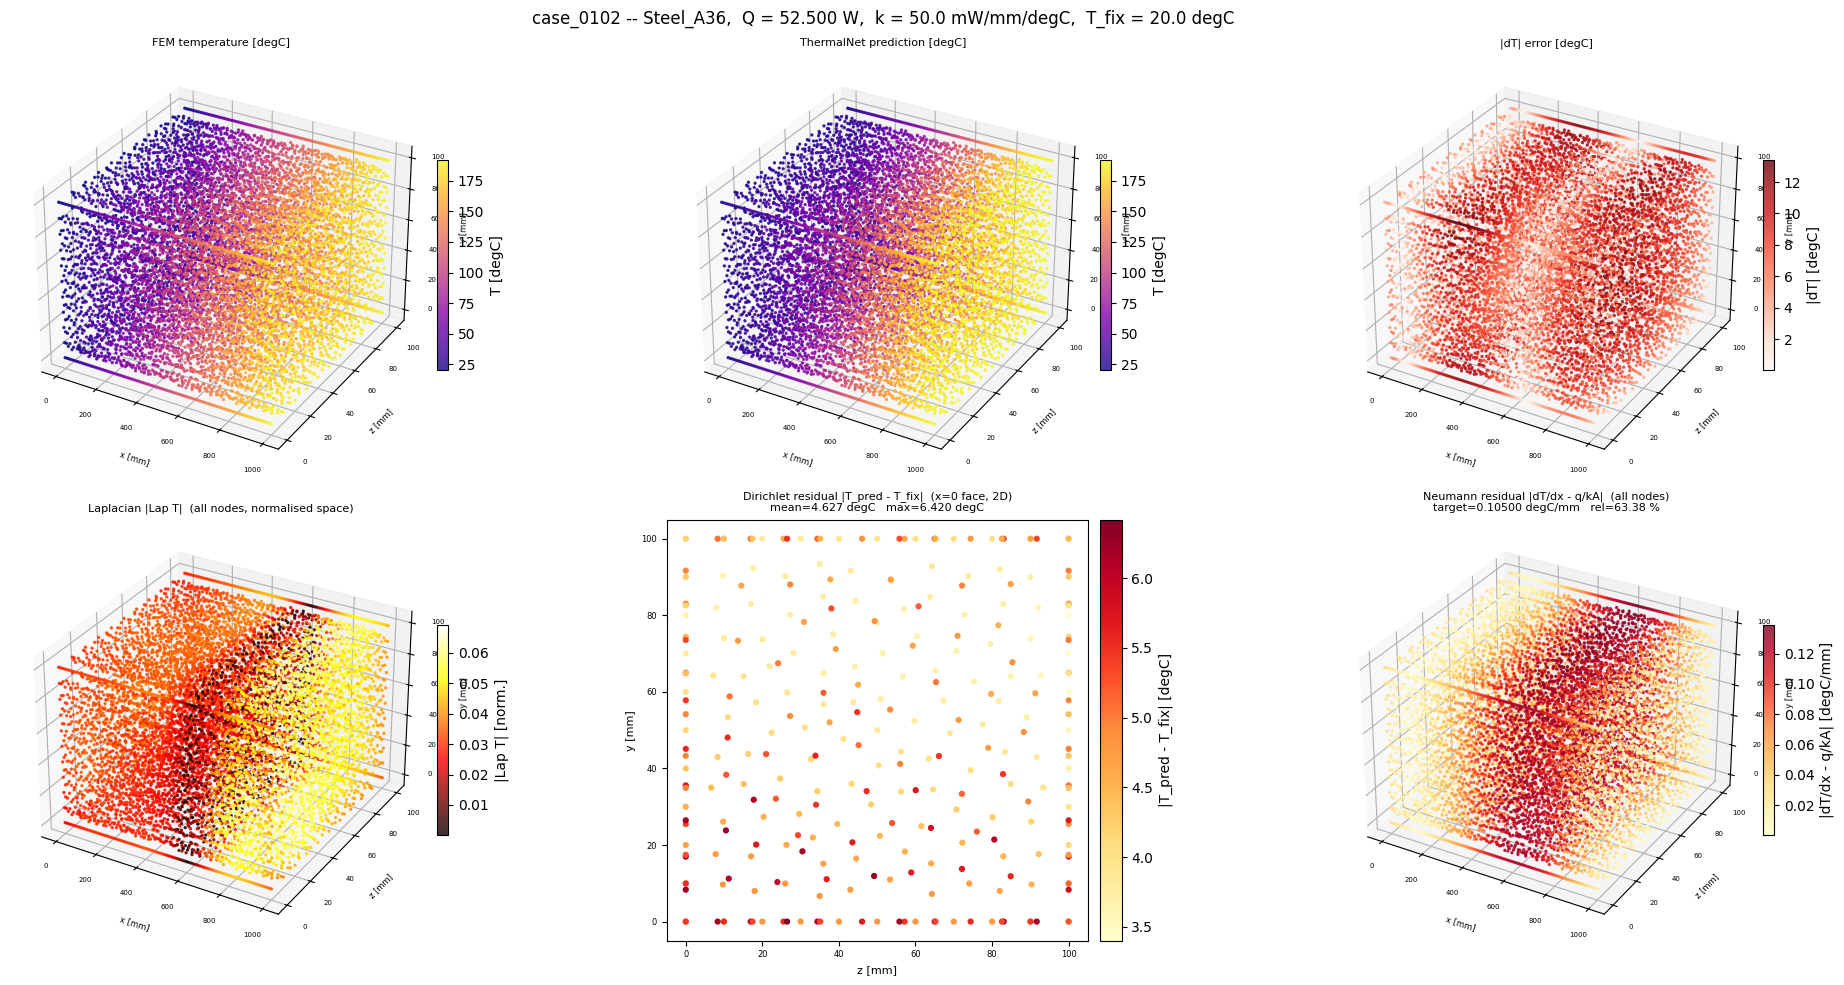

Saved -> saves/bc_overview_case_0102.png


In [48]:
# -- 2x3 overview: row1 = data fields | row2 = loss residuals ----------------
import torch

x = coords[:, 0]
y = coords[:, 1]
z = coords[:, 2]

# -- Compute per-node Laplacian AND dT/dx (batched autograd) -----------------
def compute_spatial_residuals(X_n, batch=512):
    laps, dTdx = [], []
    X_t = torch.from_numpy(X_n)
    Y_std  = float(norm['Y_std'])
    X_std0 = float(norm['X_std'][0])
    for i in range(0, len(X_t), batch):
        xb = X_t[i:i+batch].clone().requires_grad_(True)
        T  = model(xb)
        g  = torch.autograd.grad(T.sum(), xb, create_graph=True)[0][:, :3]
        dTdx.append(g[:, 0].detach().numpy() * Y_std / X_std0)
        lap = torch.zeros(len(xb))
        for j in range(3):
            g2  = torch.autograd.grad(g[:, j].sum(), xb,
                                      create_graph=False, retain_graph=True)[0]
            lap = lap + g2[:, j].detach()
        laps.append(lap.numpy())
    return np.concatenate(laps), np.concatenate(dTdx)

print('Computing spatial residuals ...')
lap_vals, dTdx_all = compute_spatial_residuals(X_n)
lap_abs = np.abs(lap_vals)

# -- Dirichlet residual: |T_pred - T_fix| at x=0 face nodes only ------------
dir_abs_face = np.abs(dir_res)          # [degC]  already computed in cell 9
y_dir = coords[dir_mask, 1]             # y-coords on Dirichlet face
z_dir = coords[dir_mask, 2]             # z-coords on Dirichlet face

# -- Neumann: |dT/dx - q/(k*A)| on all nodes ----------------------------------
neu_target  = q_mW / (k_val * 10_000.0)   # [degC/mm] analytical gradient
neu_abs_all = np.abs(dTdx_all - neu_target)

print(f'  Laplacian   mean |res| : {lap_abs.mean():.5f}   max : {lap_abs.max():.5f}')
print(f'  Dirichlet   mean |T-T_fix|: {dir_abs_face.mean():.3f} degC   max: {dir_abs_face.max():.3f}  (x=0 face, {dir_mask.sum()} nodes)')
print(f'  Neumann     target     : {neu_target:.6f} degC/mm')
print(f'              mean |res| : {neu_abs_all.mean():.6f}   rel: {neu_abs_all.mean()/neu_target*100:.2f} %')

# -- Figure -------------------------------------------------------------------
fig = plt.figure(figsize=(20, 10))
fig.suptitle(
    f'{CASE_ID} -- {params["material"]},  Q = {q_mW/1000:.3f} W,  '
    f'k = {k_val} mW/mm/degC,  T_fix = {T_fix} degC',
    fontsize=12
)

def add3d(pos):
    return fig.add_subplot(2, 3, pos, projection='3d')

def fmt3d(ax, title, fontsize=8):
    ax.set_title(title, fontsize=fontsize)
    ax.set_xlabel('x [mm]', fontsize=6)
    ax.set_ylabel('z [mm]', fontsize=6)
    ax.set_zlabel('y [mm]', fontsize=6)
    ax.tick_params(labelsize=5)

# Row 1: data fields ----------------------------------------------------------
vmin_T, vmax_T = true_C.min(), true_C.max()

ax1 = add3d(1)
sc1 = ax1.scatter(x, z, y, c=true_C, cmap='plasma', vmin=vmin_T, vmax=vmax_T, s=2, alpha=0.8)
fig.colorbar(sc1, ax=ax1, shrink=0.5, label='T [degC]', pad=0.01)
fmt3d(ax1, 'FEM temperature [degC]')

ax2 = add3d(2)
sc2 = ax2.scatter(x, z, y, c=pred_C, cmap='plasma', vmin=vmin_T, vmax=vmax_T, s=2, alpha=0.8)
fig.colorbar(sc2, ax=ax2, shrink=0.5, label='T [degC]', pad=0.01)
fmt3d(ax2, 'ThermalNet prediction [degC]')

ax3 = add3d(3)
sc3 = ax3.scatter(x, z, y, c=err, cmap='Reds', s=2, alpha=0.8)
fig.colorbar(sc3, ax=ax3, shrink=0.5, label='|dT| [degC]', pad=0.01)
fmt3d(ax3, '|dT| error [degC]')

# Row 2: physics residuals on full beam ---------------------------------------
ax4 = add3d(4)
sc4 = ax4.scatter(x, z, y, c=lap_abs, cmap='hot', s=2, alpha=0.8)
fig.colorbar(sc4, ax=ax4, shrink=0.5, label='|Lap T| [norm.]', pad=0.01)
fmt3d(ax4, 'Laplacian |Lap T|  (all nodes, normalised space)')

ax5 = fig.add_subplot(2, 3, 5)   # 2D — Dirichlet face at x=0
sc5 = ax5.scatter(z_dir, y_dir, c=dir_abs_face, cmap='YlOrRd', s=12)
fig.colorbar(sc5, ax=ax5, label='|T_pred - T_fix| [degC]', pad=0.02)
ax5.set_xlabel('z [mm]', fontsize=8)
ax5.set_ylabel('y [mm]', fontsize=8)
ax5.set_title(f'Dirichlet residual |T_pred - T_fix|  (x=0 face, 2D)\n'
              f'mean={dir_abs_face.mean():.3f} degC   max={dir_abs_face.max():.3f} degC',
              fontsize=8)
ax5.set_aspect('equal')
ax5.tick_params(labelsize=6)

ax6 = add3d(6)
sc6 = ax6.scatter(x, z, y, c=neu_abs_all, cmap='YlOrRd', s=2, alpha=0.8)
fig.colorbar(sc6, ax=ax6, shrink=0.5, label='|dT/dx - q/kA| [degC/mm]', pad=0.01)
fmt3d(ax6, f'Neumann residual |dT/dx - q/kA|  (all nodes)\n'
           f'target={neu_target:.5f} degC/mm   rel={neu_abs_all.mean()/neu_target*100:.2f} %')

plt.tight_layout()
plt.savefig(SAVES / f'bc_overview_{CASE_ID}.png', dpi=120, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print(f'Saved -> saves/bc_overview_{CASE_ID}.png')


---
## 4 — Dirichlet face analysis

At x=0, the model must predict exactly `T_fix` for every node.
We look at:
- The distribution of `T̂ - T_fix` across boundary nodes (should be zero)
- Whether the error is uniform across the face (y-z plane) or structured

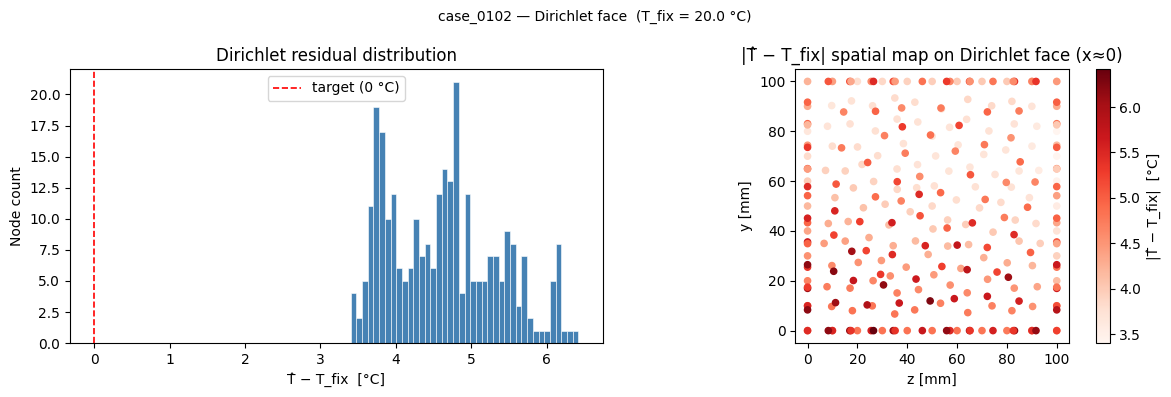

Mean |residual| = 4.6268 °C


In [49]:
y_face = coords[dir_mask, 1]   # y-coords on Dirichlet face
z_face = coords[dir_mask, 2]   # z-coords on Dirichlet face

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: distribution of signed residual
ax = axes[0]
ax.hist(dir_res, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='target (0 °C)')
ax.set_xlabel('T̂ − T_fix  [°C]')
ax.set_ylabel('Node count')
ax.set_title('Dirichlet residual distribution')
ax.legend()

# Right: spatial map on the y-z face
ax = axes[1]
sc = ax.scatter(z_face, y_face, c=np.abs(dir_res), cmap='Reds', s=20)
fig.colorbar(sc, ax=ax, label='|T̂ − T_fix|  [°C]')
ax.set_xlabel('z [mm]')
ax.set_ylabel('y [mm]')
ax.set_title('|T̂ − T_fix| spatial map on Dirichlet face (x≈0)')
ax.set_aspect('equal')

fig.suptitle(f'{CASE_ID} — Dirichlet face  (T_fix = {T_fix} °C)', fontsize=10)
plt.tight_layout()
plt.savefig(SAVES / f'bc_dirichlet_{CASE_ID}.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Mean |residual| = {np.abs(dir_res).mean():.4f} °C')

---
## 5 — Neumann face analysis

At x=L, the model's temperature gradient `∂T̂/∂x` must match `q/(k·A)`.
This is the **critical** loss for extrapolation — the slope relationship.

We look at:
- Predicted vs target gradient (should lie on y=x line)
- Spatial distribution of the gradient error on the y-z face
- Whether the prediction is systematically under/over-estimating the slope

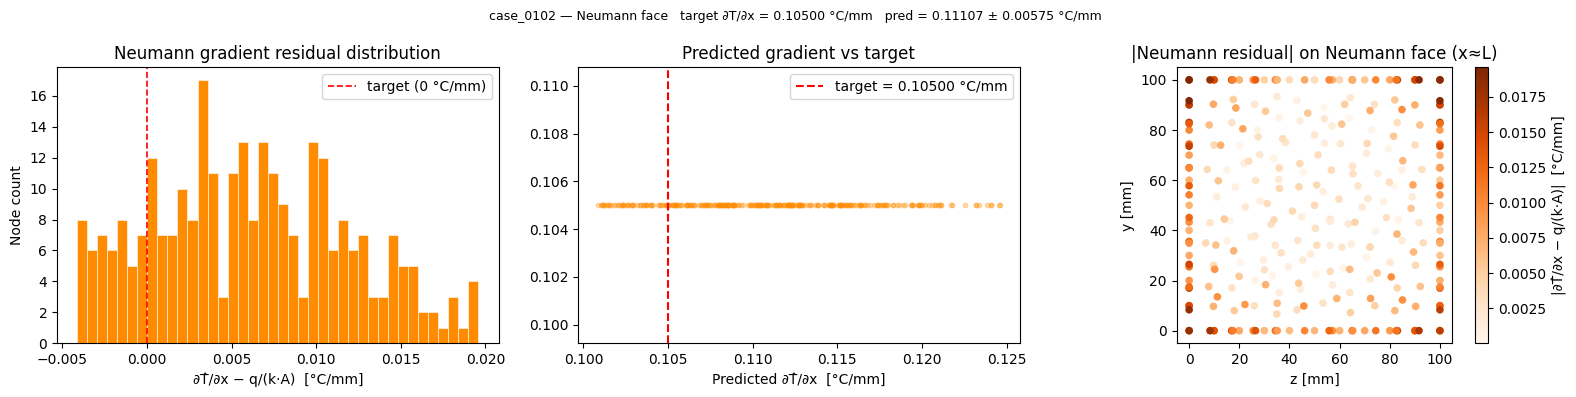

Relative Neumann error: 6.44 %


In [50]:
y_face_neu = coords[neu_mask, 1]
z_face_neu = coords[neu_mask, 2]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: distribution of signed residual
ax = axes[0]
ax.hist(neu_res, bins=40, color='darkorange', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='target (0 °C/mm)')
ax.set_xlabel('∂T̂/∂x − q/(k·A)  [°C/mm]')
ax.set_ylabel('Node count')
ax.set_title('Neumann gradient residual distribution')
ax.legend()

# Middle: predicted vs target gradient (scatter)
ax = axes[1]
ax.scatter(neu_pred_grad, [neu_target_grad] * len(neu_pred_grad),
           alpha=0.3, s=10, color='darkorange')
ax.axvline(neu_target_grad, color='red', linestyle='--', linewidth=1.5,
           label=f'target = {neu_target_grad:.5f} °C/mm')
ax.set_xlabel('Predicted ∂T̂/∂x  [°C/mm]')
ax.set_title('Predicted gradient vs target')
ax.legend()

# Right: spatial map on y-z face
ax = axes[2]
sc = ax.scatter(z_face_neu, y_face_neu, c=np.abs(neu_res), cmap='Oranges', s=20)
fig.colorbar(sc, ax=ax, label='|∂T̂/∂x − q/(k·A)|  [°C/mm]')
ax.set_xlabel('z [mm]')
ax.set_ylabel('y [mm]')
ax.set_title('|Neumann residual| on Neumann face (x≈L)')
ax.set_aspect('equal')

fig.suptitle(
    f'{CASE_ID} — Neumann face   target ∂T/∂x = {neu_target_grad:.5f} °C/mm   '
    f'pred = {neu_pred_grad.mean():.5f} ± {neu_pred_grad.std():.5f} °C/mm',
    fontsize=9
)
plt.tight_layout()
plt.savefig(SAVES / f'bc_neumann_{CASE_ID}.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Relative Neumann error: {np.abs(neu_res).mean()/neu_target_grad*100:.2f} %')

---
## 6 — Multi-case comparison: Steel_A36, all Q levels

This is the key extrapolation test. We compare the **5 test Q values** for one
material to see how BC residuals scale outside the training range.

Expected:
- `extrap-below` (Q=0.1W, 0.3W): very small residuals — tiny gradients
- `interp` (Q=52.5W): small residuals — within training range
- `extrap-above` (Q=200W, 500W): large Neumann residual if slope is wrong

In [51]:
STEEL_CASES = [
    ('case_0100',  100,       'extrap-below',  'C0'),
    ('case_0101',  300,       'extrap-below',  'C1'),
    ('case_0102',  52_500,    'interp',        'C2'),
    ('case_0103',  200_000,   'extrap-above',  'C3'),
    ('case_0104',  500_000,   'extrap-above',  'C4'),
]

results = []
for case_id, q_expected, regime, color in STEEL_CASES:
    c = load_case(case_id)
    q_mW   = c['params']['q_total_mW']
    T_fix  = c['params']['T_fix_C']
    k_val  = c['k_val']
    err    = np.abs(c['pred_C'] - c['true_C'])

    dm, dr         = compute_dirichlet_residuals(c['X_n'], c['pred_C'], T_fix)
    nm, ng, tg, nr = compute_neumann_residuals(c['X_n'], q_mW, k_val)

    results.append(dict(
        case_id=case_id, q_W=q_mW/1000, regime=regime, color=color,
        mae=err.mean(), max_err=err.max(),
        dir_mae=np.abs(dr).mean(), dir_max=np.abs(dr).max(),
        neu_target=tg,
        neu_pred_mean=ng.mean(),
        neu_mae=np.abs(nr).mean(), neu_max=np.abs(nr).max(),
        neu_rel_pct=np.abs(nr).mean()/tg*100 if tg > 0 else np.nan,
    ))
    print(f'  {case_id}  Q={q_mW/1000:>8.2f} W  ({regime:14s})  '
          f'MAE={err.mean():7.2f}°C  |Dir|={np.abs(dr).mean():.4f}°C  '
          f'|Neu|={np.abs(nr).mean():.5f}°C/mm  ({np.abs(nr).mean()/tg*100:.1f}%)')

  case_0100  Q=    0.10 W  (extrap-below  )  MAE=   0.35°C  |Dir|=0.5163°C  |Neu|=0.00013°C/mm  (63.2%)
  case_0101  Q=    0.30 W  (extrap-below  )  MAE=   0.23°C  |Dir|=0.3106°C  |Neu|=0.00021°C/mm  (35.6%)
  case_0102  Q=   52.50 W  (interp        )  MAE=   6.43°C  |Dir|=4.6268°C  |Neu|=0.00676°C/mm  (6.4%)
  case_0103  Q=  200.00 W  (extrap-above  )  MAE=  98.52°C  |Dir|=44.0312°C  |Neu|=0.18916°C/mm  (47.3%)
  case_0104  Q=  500.00 W  (extrap-above  )  MAE= 478.81°C  |Dir|=115.1121°C  |Neu|=0.80221°C/mm  (80.2%)


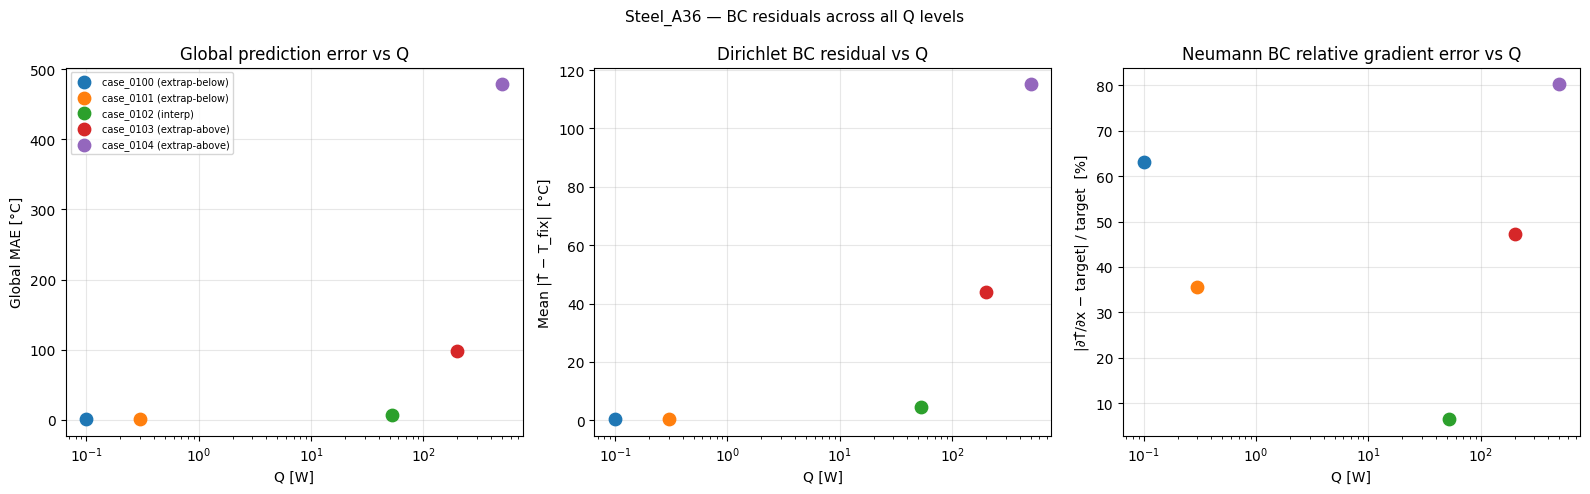

In [52]:
q_vals     = [r['q_W']         for r in results]
mae_vals   = [r['mae']         for r in results]
dir_vals   = [r['dir_mae']     for r in results]
neu_vals   = [r['neu_mae']     for r in results]
neu_rel    = [r['neu_rel_pct'] for r in results]
colors     = [r['color']       for r in results]
regimes    = [r['regime']      for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Global MAE vs Q
ax = axes[0]
for r in results:
    ax.scatter(r['q_W'], r['mae'], color=r['color'], s=80,
               label=f"{r['case_id']} ({r['regime']})", zorder=3)
ax.set_xscale('log')
ax.set_xlabel('Q [W]')
ax.set_ylabel('Global MAE [°C]')
ax.set_title('Global prediction error vs Q')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Panel 2: |Dirichlet residual| vs Q
ax = axes[1]
for r in results:
    ax.scatter(r['q_W'], r['dir_mae'], color=r['color'], s=80,
               label=r['regime'], zorder=3)
ax.set_xscale('log')
ax.set_xlabel('Q [W]')
ax.set_ylabel('Mean |T̂ − T_fix|  [°C]')
ax.set_title('Dirichlet BC residual vs Q')
ax.grid(True, alpha=0.3)

# Panel 3: |Neumann residual| relative % vs Q
ax = axes[2]
for r in results:
    ax.scatter(r['q_W'], r['neu_rel_pct'], color=r['color'], s=80,
               label=r['regime'], zorder=3)
ax.set_xscale('log')
ax.set_xlabel('Q [W]')
ax.set_ylabel('|∂T̂/∂x − target| / target  [%]')
ax.set_title('Neumann BC relative gradient error vs Q')
ax.grid(True, alpha=0.3)

fig.suptitle('Steel_A36 — BC residuals across all Q levels', fontsize=11)
plt.tight_layout()
plt.savefig(SAVES / 'bc_losses_vs_Q_Steel_A36.png', dpi=120, bbox_inches='tight')
plt.show()

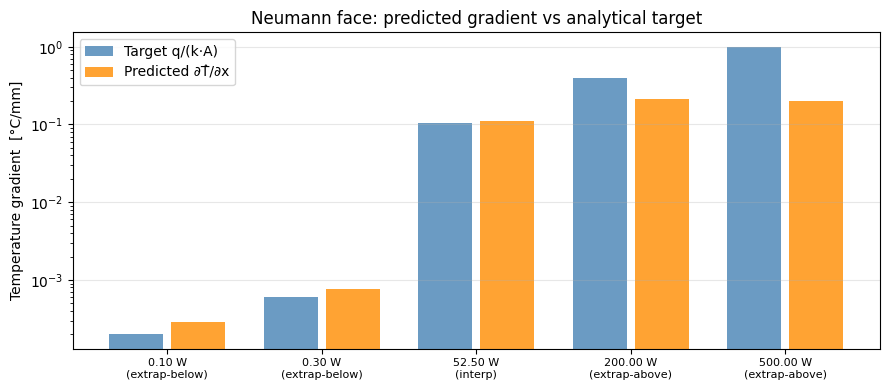

If bars are equal → Neumann loss is working. If orange << blue for extrap-above → slope underestimated.


In [53]:
# Predicted vs target gradient: bar comparison across Q levels
fig, ax = plt.subplots(figsize=(9, 4))

x_pos     = np.arange(len(results))
targets   = [r['neu_target']    for r in results]
preds     = [r['neu_pred_mean'] for r in results]
labels    = [f"{r['q_W']:.2f} W\n({r['regime']})" for r in results]

bars_t = ax.bar(x_pos - 0.2, targets, width=0.35, label='Target q/(k·A)', color='steelblue', alpha=0.8)
bars_p = ax.bar(x_pos + 0.2, preds,   width=0.35, label='Predicted ∂T̂/∂x', color='darkorange', alpha=0.8)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Temperature gradient  [°C/mm]')
ax.set_title('Neumann face: predicted gradient vs analytical target')
ax.legend()
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(SAVES / 'bc_neumann_gradient_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('If bars are equal → Neumann loss is working. If orange << blue for extrap-above → slope underestimated.')

---
## 7 — Summary table: all 25 test cases

Compute Dirichlet and Neumann residuals for every test case and compare them
to the global MAE.

In [54]:
manifest   = json.loads((ELMER_CASES / 'vtk_manifest.json').read_text())
test_cases = [e for e in manifest['cases']
              if e.get('success') and e.get('split') == 'test']

print(f'Running BC analysis on {len(test_cases)} test cases …')

all_rows = []
for entry in test_cases:
    cid = entry['case_id']
    try:
        c      = load_case(cid)
        q_mW   = c['params']['q_total_mW']
        T_fix  = c['params']['T_fix_C']
        k_val  = c['k_val']
        err    = np.abs(c['pred_C'] - c['true_C'])

        dm, dr         = compute_dirichlet_residuals(c['X_n'], c['pred_C'], T_fix)
        nm, ng, tg, nr = compute_neumann_residuals(c['X_n'], q_mW, k_val)

        all_rows.append(dict(
            case_id=cid,
            material=c['params']['material'],
            q_W=q_mW/1000,
            regime=entry.get('regime', '?'),
            mae=err.mean(),
            dir_mae=np.abs(dr).mean(),
            neu_target=tg,
            neu_mae=np.abs(nr).mean(),
            neu_rel_pct=np.abs(nr).mean()/tg*100 if tg > 0 else np.nan,
        ))
    except Exception as ex:
        print(f'  SKIP {cid}: {ex}')

# Print table
hdr = (f"{'Case':12s}  {'Material':22s}  {'Q [W]':>9}  {'Regime':14s}  "
       f"{'MAE [°C]':>9}  {'|Dir| [°C]':>10}  {'|Neu| [°C/mm]':>13}  {'Neu [%]':>8}")
print('\n' + hdr)
print('-' * len(hdr))
for r in all_rows:
    print(f"{r['case_id']:12s}  {r['material']:22s}  {r['q_W']:9.3f}  "
          f"{r['regime']:14s}  {r['mae']:9.3f}  {r['dir_mae']:10.4f}  "
          f"{r['neu_mae']:13.6f}  {r['neu_rel_pct']:8.2f}")

Running BC analysis on 25 test cases …

Case          Material                    Q [W]  Regime           MAE [°C]  |Dir| [°C]  |Neu| [°C/mm]   Neu [%]
---------------------------------------------------------------------------------------------------------------
case_0100     Steel_A36                   0.100  ?                   0.351      0.5163       0.000126     63.19
case_0101     Steel_A36                   0.300  ?                   0.233      0.3106       0.000213     35.57
case_0102     Steel_A36                  52.500  ?                   6.430      4.6268       0.006761      6.44
case_0103     Steel_A36                 200.000  ?                  98.521     44.0312       0.189161     47.29
case_0104     Steel_A36                 500.000  ?                 478.810    115.1121       0.802210     80.22
case_0205     Steel_S355                  0.100  ?                   0.341      0.5395       0.000130     62.63
case_0206     Steel_S355                  0.300  ?              

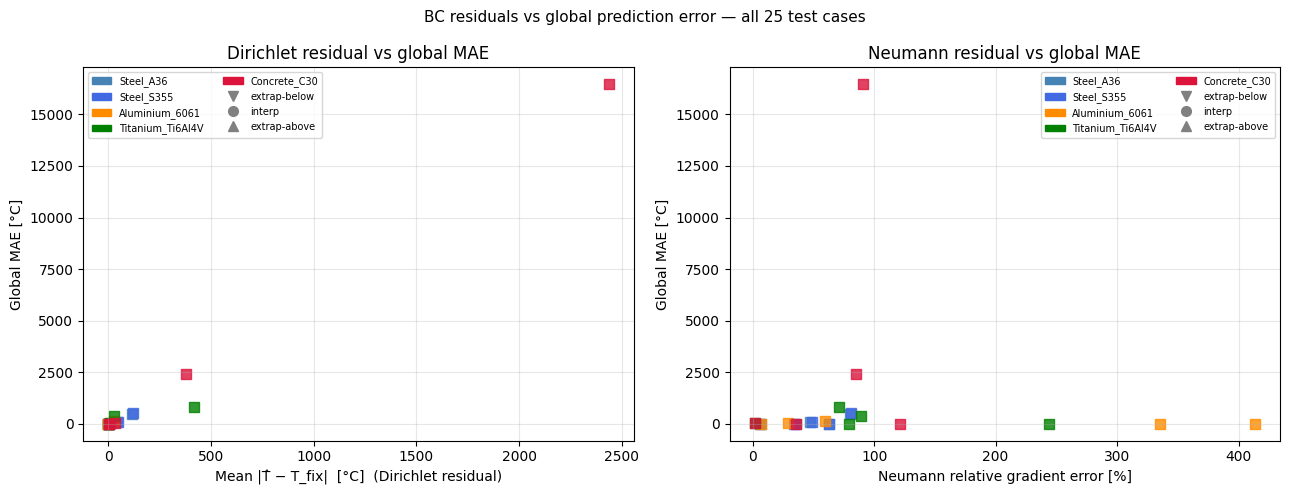

Spearman ρ(Dirichlet residual, MAE) = 0.975  (p=1.334e-16)
Spearman ρ(Neumann residual,   MAE) = 0.102  (p=6.265e-01)

If ρ_neu > ρ_dir → Neumann residual is a better predictor of total error (expected).


In [55]:
# Scatter: BC residuals vs MAE, coloured by material, marker by regime
MATERIAL_COLORS = {
    'Steel_A36':        'steelblue',
    'Steel_S355':       'royalblue',
    'Aluminium_6061':   'darkorange',
    'Titanium_Ti6Al4V': 'green',
    'Concrete_C30':     'crimson',
}
REGIME_MARKERS = {'extrap-below': 'v', 'interp': 'o', 'extrap-above': '^', '?': 's'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for r in all_rows:
    col = MATERIAL_COLORS.get(r['material'], 'gray')
    mk  = REGIME_MARKERS.get(r['regime'], 's')

    axes[0].scatter(r['dir_mae'], r['mae'], color=col, marker=mk, s=60, alpha=0.8)
    axes[1].scatter(r['neu_rel_pct'], r['mae'], color=col, marker=mk, s=60, alpha=0.8)

# Legend patches
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
mat_handles = [mpatches.Patch(color=c, label=m) for m, c in MATERIAL_COLORS.items()]
reg_handles = [mlines.Line2D([], [], color='gray', marker=mk, linestyle='None',
                              markersize=7, label=reg)
               for reg, mk in REGIME_MARKERS.items() if reg != '?']

axes[0].set_xlabel('Mean |T̂ − T_fix|  [°C]  (Dirichlet residual)')
axes[0].set_ylabel('Global MAE [°C]')
axes[0].set_title('Dirichlet residual vs global MAE')
axes[0].legend(handles=mat_handles + reg_handles, fontsize=7, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Neumann relative gradient error [%]')
axes[1].set_ylabel('Global MAE [°C]')
axes[1].set_title('Neumann residual vs global MAE')
axes[1].legend(handles=mat_handles + reg_handles, fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

fig.suptitle('BC residuals vs global prediction error — all 25 test cases', fontsize=11)
plt.tight_layout()
plt.savefig(SAVES / 'bc_residuals_vs_mae_all_cases.png', dpi=120, bbox_inches='tight')
plt.show()

# Spearman correlation
mae_arr = np.array([r['mae'] for r in all_rows])
dir_arr = np.array([r['dir_mae'] for r in all_rows])
neu_arr = np.array([r['neu_rel_pct'] for r in all_rows])

rho_dir, p_dir = spearmanr(dir_arr, mae_arr)
rho_neu, p_neu = spearmanr(neu_arr, mae_arr)
print(f'Spearman ρ(Dirichlet residual, MAE) = {rho_dir:.3f}  (p={p_dir:.3e})')
print(f'Spearman ρ(Neumann residual,   MAE) = {rho_neu:.3f}  (p={p_neu:.3e})')
print('\nIf ρ_neu > ρ_dir → Neumann residual is a better predictor of total error (expected).')

---
## 8 — Aggregate statistics by regime

Compare how BC losses behave across the three Q regimes.

In [56]:
from collections import defaultdict

by_regime = defaultdict(list)
for r in all_rows:
    by_regime[r['regime']].append(r)

print(f"{'Regime':14s}  {'N':>3}  {'MAE [°C]':>12}  {'|Dir| [°C]':>12}  {'|Neu| [%]':>12}")
print('-' * 60)
for regime in ['extrap-below', 'interp', 'extrap-above']:
    rows = by_regime.get(regime, [])
    if not rows:
        continue
    mae_m  = np.mean([r['mae']         for r in rows])
    dir_m  = np.mean([r['dir_mae']     for r in rows])
    neu_m  = np.mean([r['neu_rel_pct'] for r in rows])
    print(f"{regime:14s}  {len(rows):3d}  {mae_m:12.3f}  {dir_m:12.4f}  {neu_m:12.2f}")

print("\nKey question: is |Neu [%]| largest for extrap-above?")
print("If yes → Neumann loss correctly identifies the root cause of extrapolation failure.")

Regime            N      MAE [°C]    |Dir| [°C]     |Neu| [%]
------------------------------------------------------------

Key question: is |Neu [%]| largest for extrap-above?
If yes → Neumann loss correctly identifies the root cause of extrapolation failure.


---
## Key questions to read from the plots

| Question | Where to look |
|----------|---------------|
| Is T̂(x=0) = T_fix? | Section 4 — histogram centered on 0? |
| Is the Dirichlet error uniform across the face? | Section 4 — spatial map structured or noise? |
| Is ∂T̂/∂x = q/(k·A) at x=L? | Section 5 — predicted bar ≈ target bar? |
| Does Neumann error grow with Q (extrapolation)? | Section 6 — panel 3 rising for extrap-above? |
| Is slope systematically under/over-estimated? | Section 6 — orange < blue for high Q? |
| Are BC losses correlated with global MAE? | Section 7 — Spearman ρ, especially for Neumann |
| Which regime is hardest for each BC? | Section 8 — aggregate table |